In [1]:
import pwbarycentres as pwb
from graph_dp import SinkhornDataProcessor
from utils import *

import pickle
import torch

import os 


In [2]:
assert 0

AssertionError: 

# Sptail bias

### circular cases for increasing spread
I think I should also explore intensity and shape errors in this simple setting

In [ ]:
# I should abstract this...
times = [0, 10, 20, 30, 40, 50]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_circle_ensemble(mem, t, path_to_data, seed_pert=42, diameter=None)

        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_circle_ensemble(0, t, path_to_data)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


cases with all correct spatial extend - no bias. but transport bias.

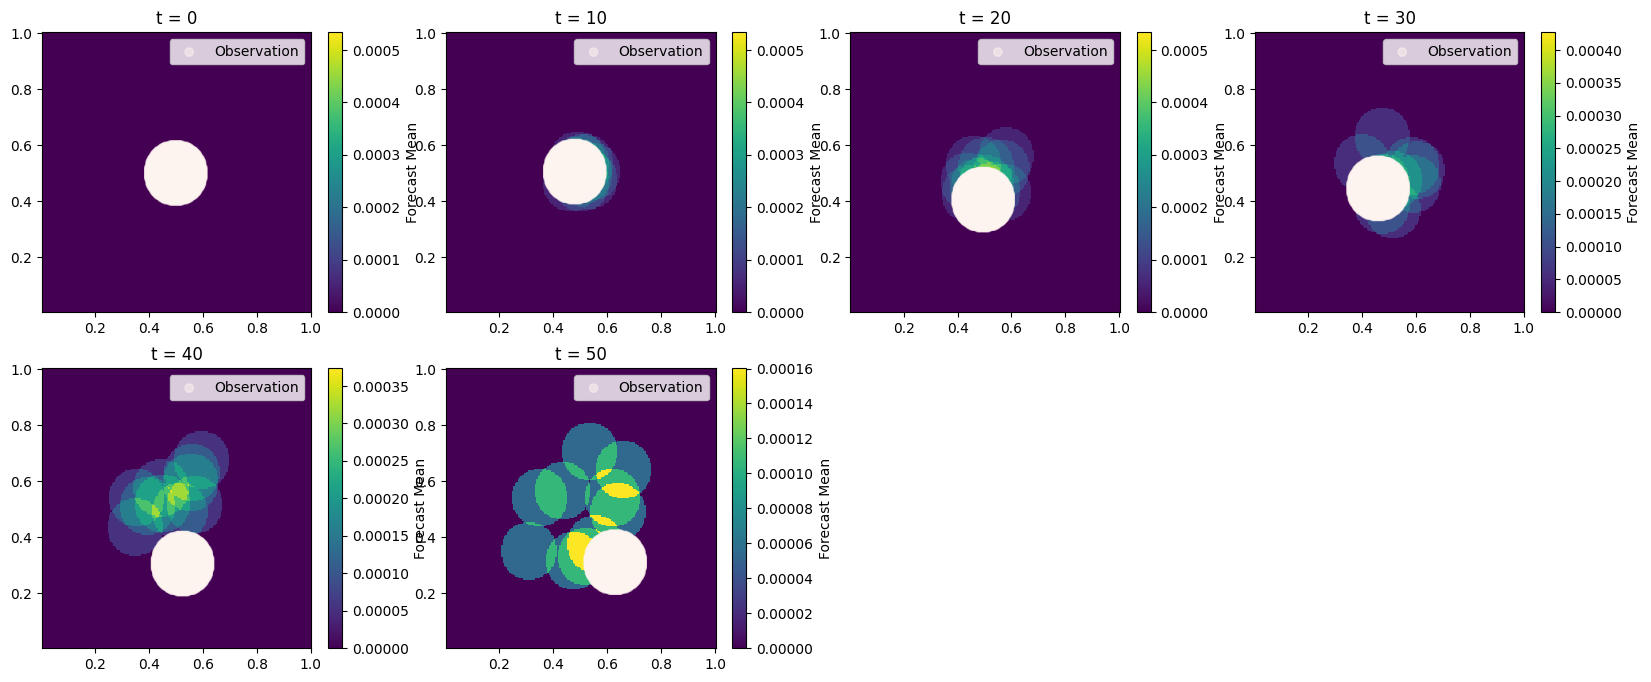

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_un_1a.png', dpi=300)

#### Cases will all too small events - spatial bias

In [ ]:
# I should abstract this...
times = [0, 10, 20, 30, 40, 50]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_circle_ensemble(mem, t, path_to_data, seed_pert=42, diameter=40)

        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_circle_ensemble(0, t, path_to_data)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


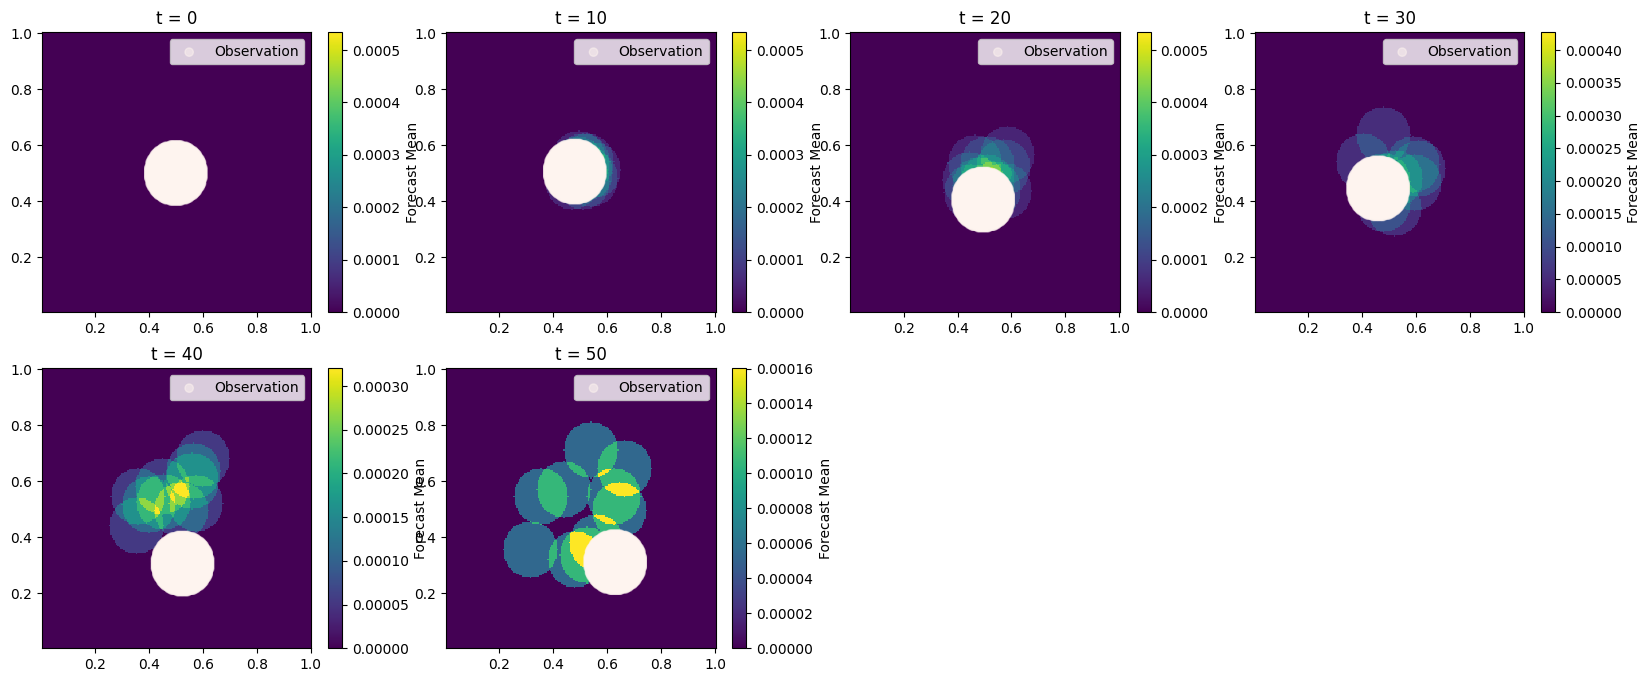

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_un_1b.png', dpi=300)

In [ ]:
# I should abstract this...
times = [0, 10, 20, 30, 40, 50]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_circle_ensemble(mem, t, path_to_data, seed_pert=42, diameter=60)

        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_circle_ensemble(0, t, path_to_data)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


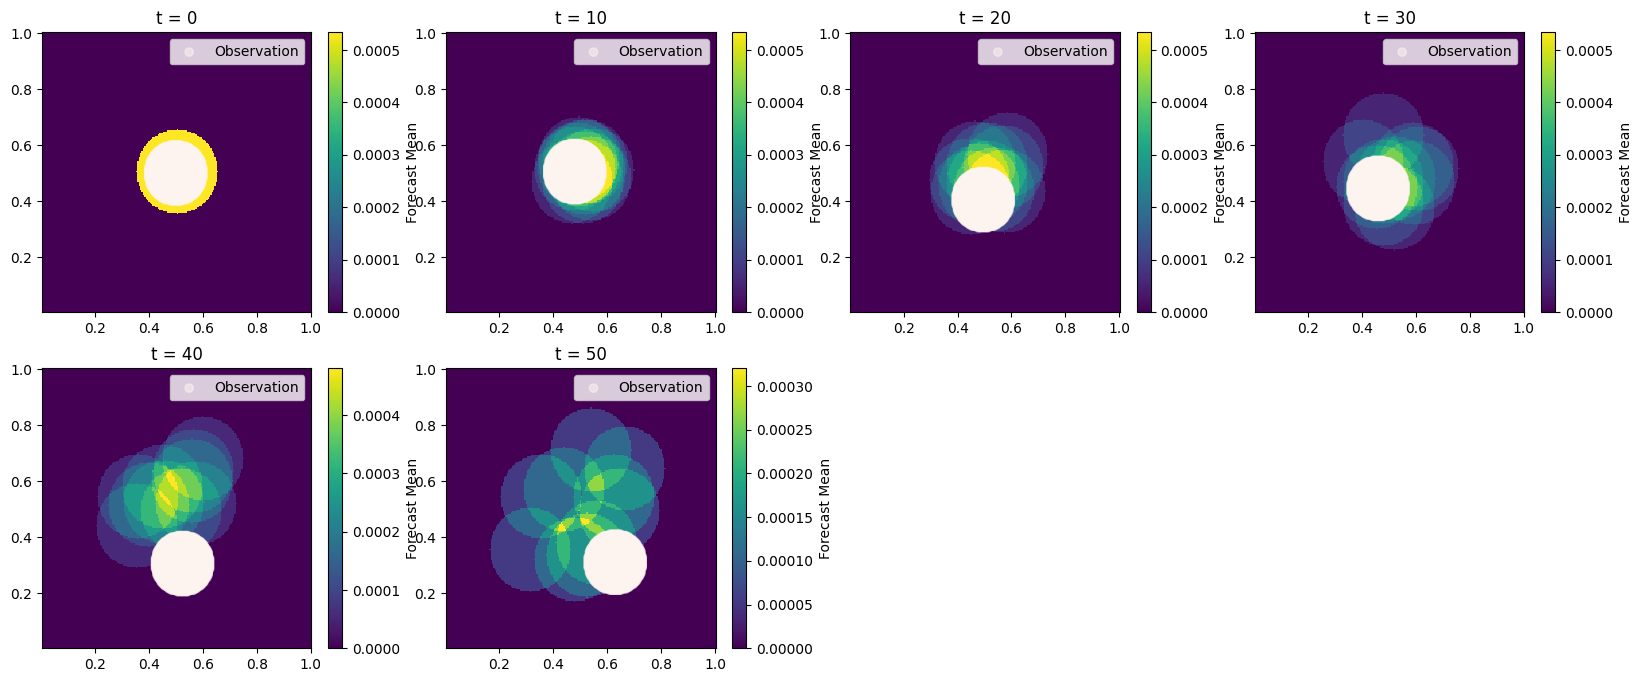

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_un_1c.png', dpi=300)

mixed random sized events

In [ ]:
# I should abstract this...
times = [0, 10, 20, 30, 40, 50]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_circle_ensemble(mem, t, path_to_data, seed_pert=42, diameter=np.random.choice(np.arange(20, 60)))

        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_circle_ensemble(0, t, path_to_data)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


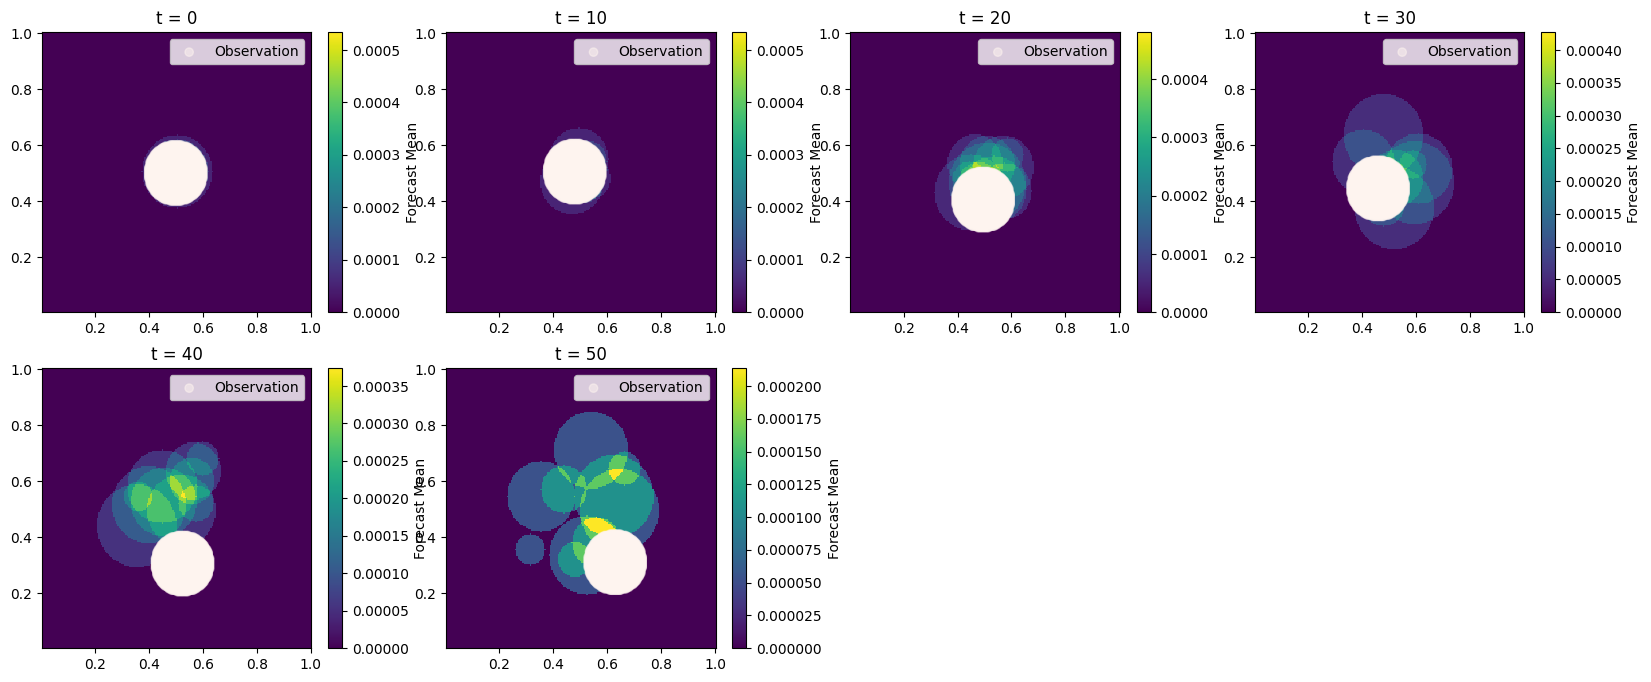

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_un_1d.png', dpi=300)

# Intesity error without translation

### elipses with different heights

In [ ]:
# I should abstract this...
times = [0, 1, 2, 3, 4, 5]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_ellipse_ensemble(mem, 0, path_to_data, seed_pert=9, case='E1', amp_scale=0.05*t)
        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_ellipse_ensemble(mem, 0, path_to_data, seed_pert=9, case='E1', amp_scale=0.05*t)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0882027
0.9713708
0.9691489
1.0284394
1.0784712
1.0190597
0.92408603
0.896773
0.9399437
1.1083418
1.1764052
0.94274145
0.9382975
1.0568788
1.1569422
1.0381193
0.84817207
0.7935459
0.8798874
1.2166836
1.2646079
0.9141122
0.9074463
1.0853182
1.2354132
1.0571792
0.77225816
0.6903188
0.81983113
1.3250253
1.3528105
0.885483
0.87659514
1.1137575
1.3138843
1.0762389
0.6963441
0.58709174
0.7597748
1.433367
1.4410131
0.8568537
0.8457438
1.1421969
1.3923554
1.0952985
0.6204301
0.48386472
0.69971853
1.5417088


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


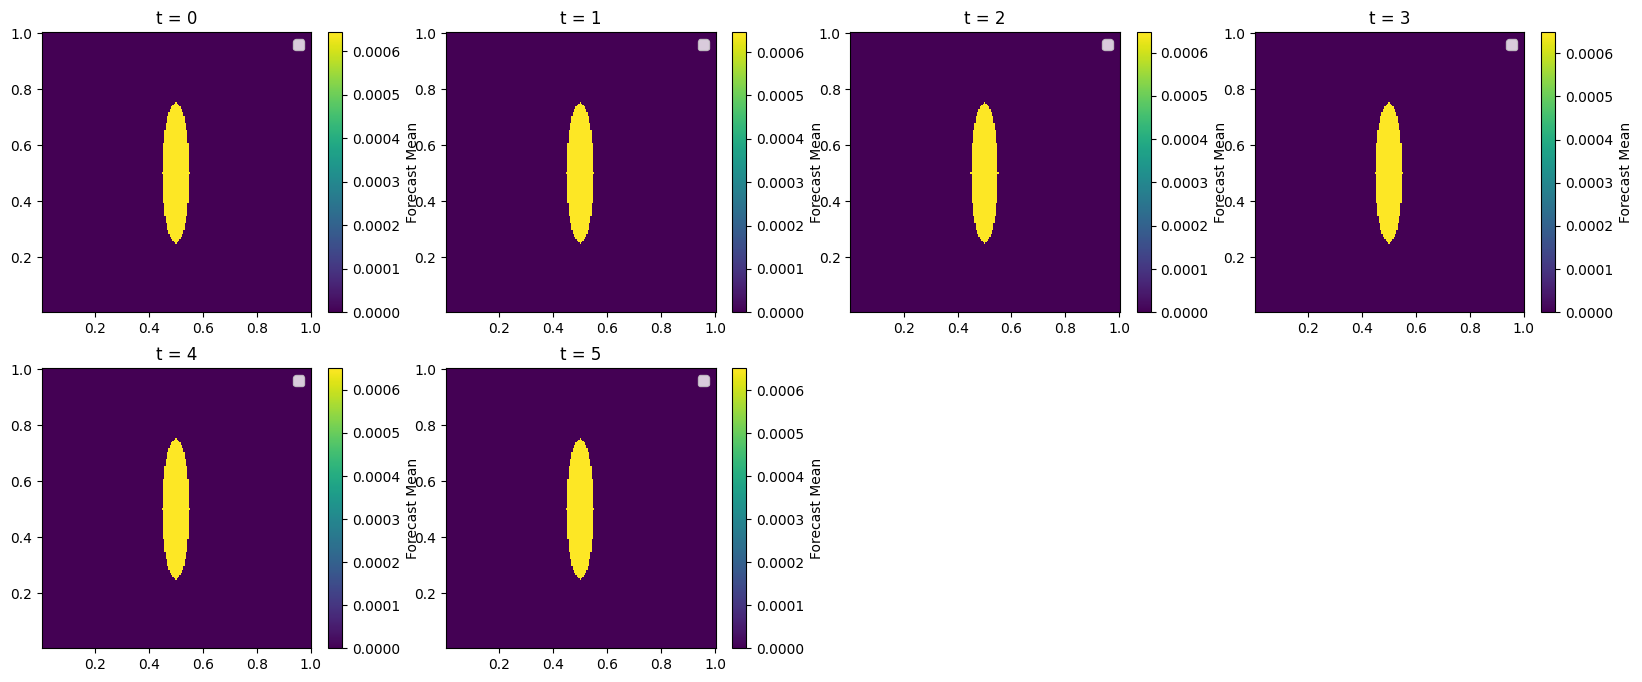

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    # ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_un_2.png', dpi=300)

### two step version

In [4]:
# I should abstract this...
times = [0, 10, 20, 30, 40, 50]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_intensity_errors_ensemble(mem, np.random.normal(scale=0.05*t), 1*t//2, path_to_data, seed_pert=1, diameter=100)
        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_intensity_errors_ensemble(0, np.random.normal(scale=0.05*t), 1*t//2, path_to_data, seed_pert=1, diameter=100)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


In [11]:
np.unique(obs[0][obs[0]>0])

array([0.00053376, 0.00141884], dtype=float32)

/tmp/ipykernel_177926/3682279159.py:18: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


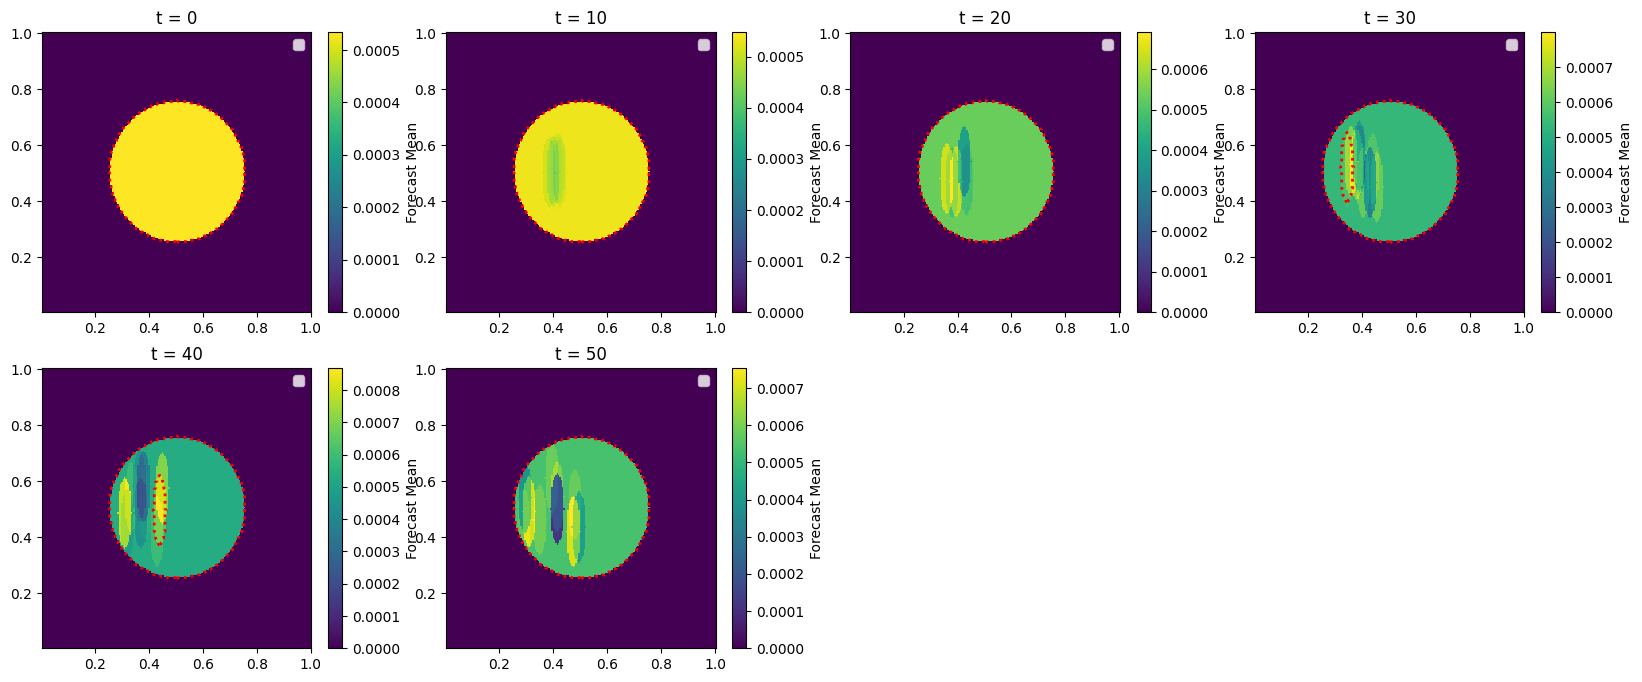

In [12]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    # ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    mask = obs[0]>0
    ax.contour(
        X[:, :, 0],
        X[:, :, 1],
        mask.astype(int),
        levels=[0],
        colors='red',
        linestyles='dotted',
        linewidths=2,
        label='Observation'
    )
    ax.legend()

plt.savefig('dataset_un_3.png', dpi=300)

### extreme events, both correct and not 

In [13]:
# I should abstract this...
times = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        if mem in [k for k in range(t)]:
            F, X = generate_extreme_event(mem, 2, 5, 5, path_to_data, seed_pert=1, diameter=100)
        else:
            F, X = generate_intensity_errors_ensemble(mem, 0, 0, path_to_data, seed_pert=1, diameter=100)
        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_extreme_event(0, 2, 5, 5, path_to_data, seed_pert=1, diameter=100)
    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


In [19]:
np.unique(obs[0][obs[0]>0])

array([0.00053376, 0.00160128], dtype=float32)

/tmp/ipykernel_177926/4249974892.py:18: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

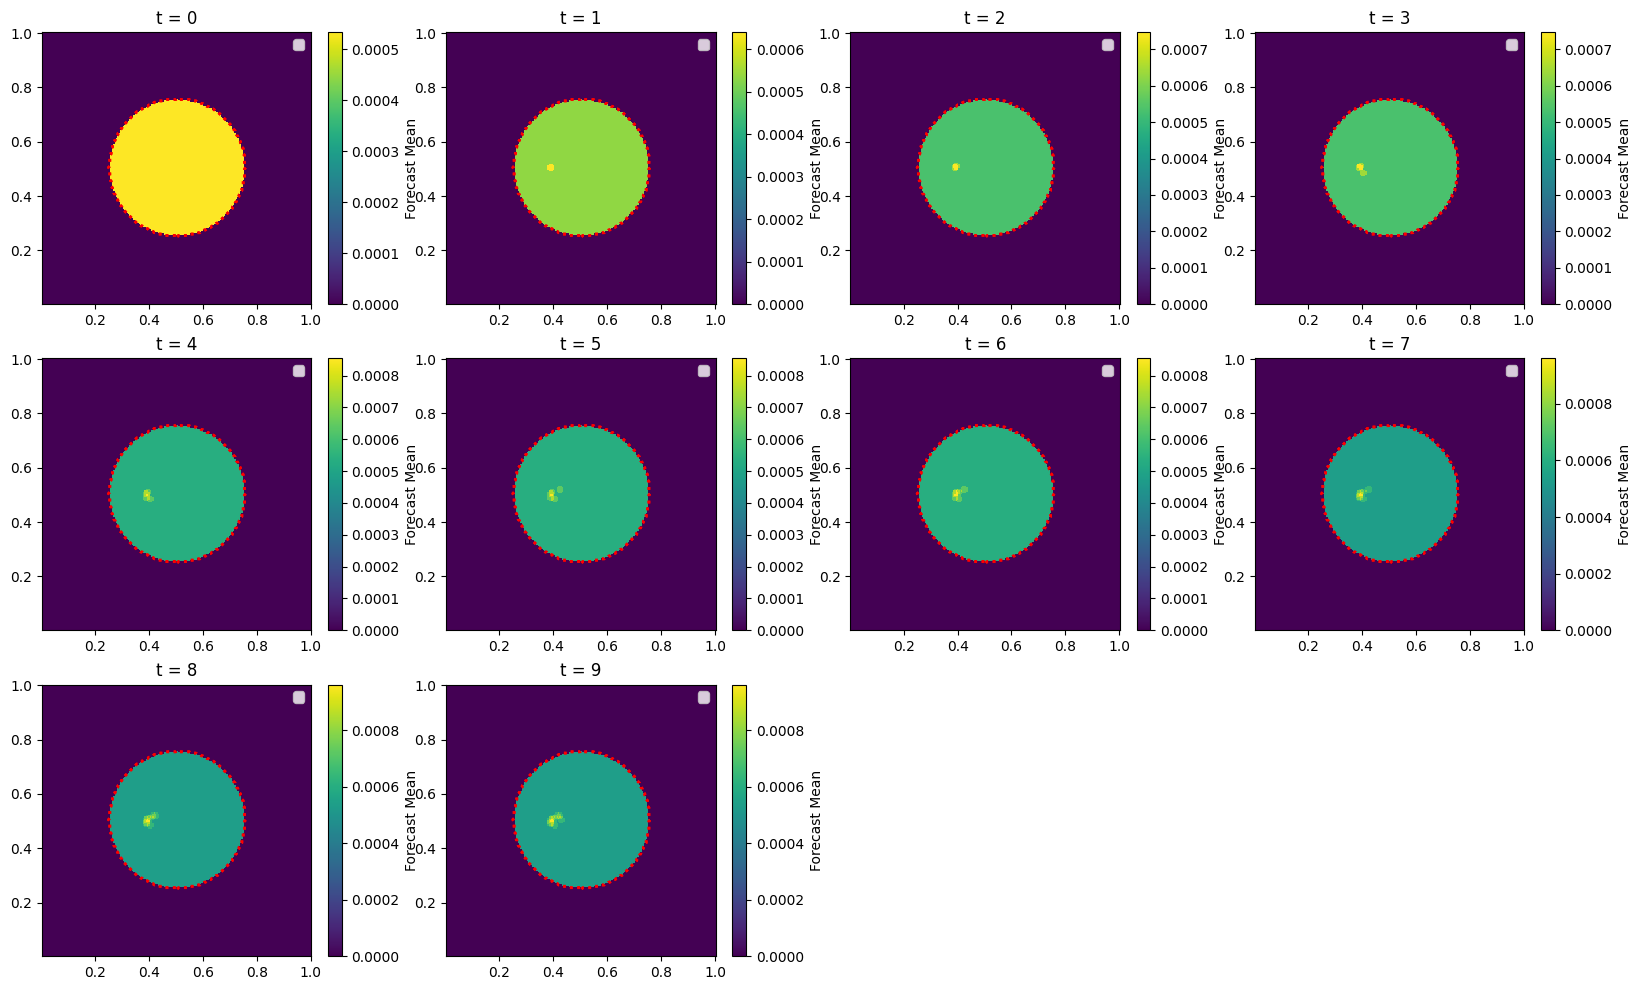

In [20]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    # ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    mask = obs[0]>0
    ax.contour(
        X[:, :, 0],
        X[:, :, 1],
        mask.astype(int),
        levels=[0, 0.0016],
        colors='red',
        linestyles='dotted',
        linewidths=2,
        label='Observation'
    )
    ax.legend()

plt.savefig('dataset_un_4.png', dpi=300)

### multiscale events

In [3]:
# I should abstract this...
times = [0, 5, 10, 15, 20]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_multiscale_ellipse_ensemble(mem, t, path_to_data, seed_pert=1)
        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_multiscale_ellipse_ensemble(0, t, path_to_data, seed_pert=1)
    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


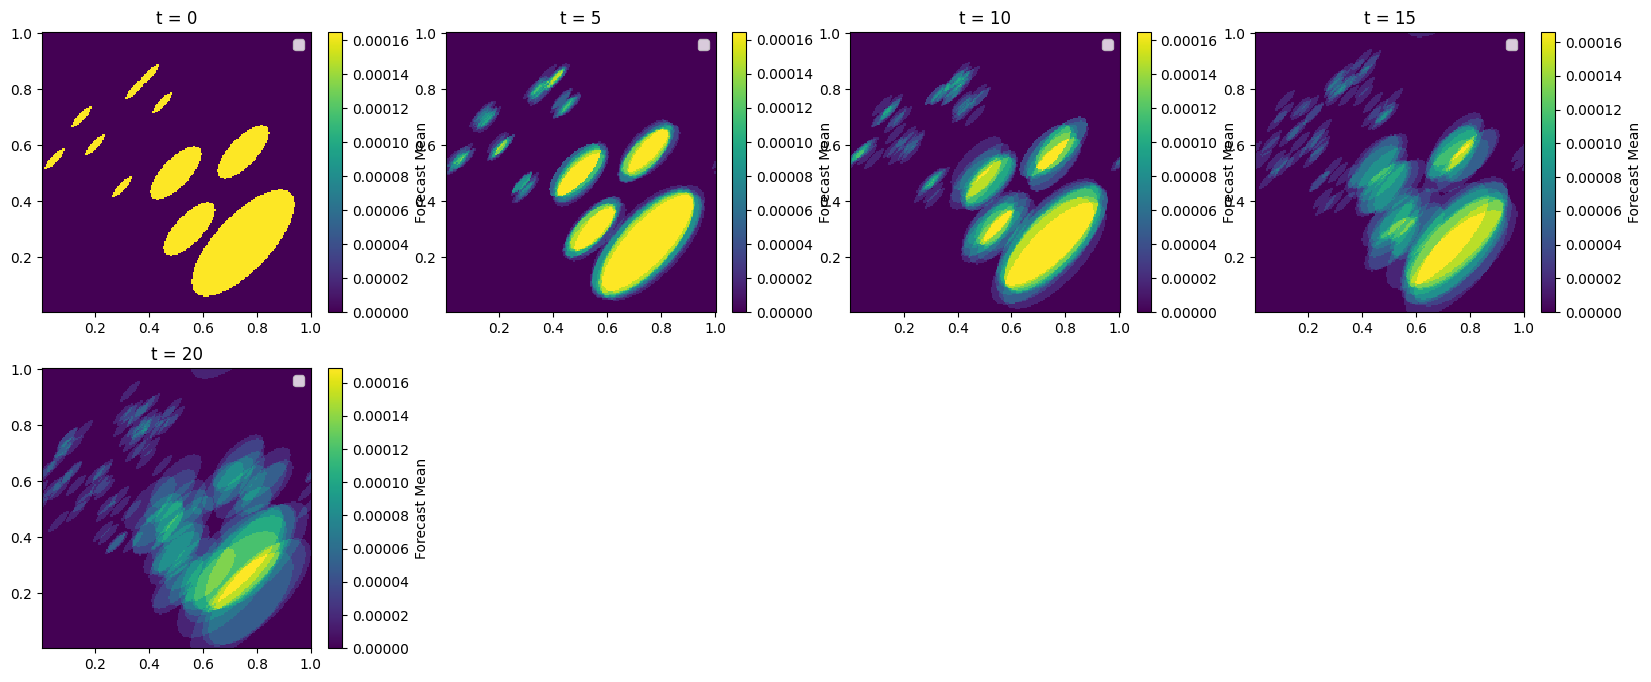

In [4]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    # ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_un_5.png', dpi=300)